# Advanced Seaborn — Part 2 & Titanic EDA  v.ekc-c

Two new high-level Seaborn functions — `displot` and `relplot` — plus a full EDA group activity on the **Titanic dataset**.

| Section | Topic |
|---------|-------|
| 1 | Setup & Warm-Up |
| 2 | `displot` — Faceted Distribution Plots |
| 3 | `relplot` — Faceted Relationship Plots |
| 4 | 🔬 Titanic EDA Activity |
| Appendix | Quick Reference |


---
## 1. Setup & Warm-Up

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [6, 3]
plt.rcParams['figure.dpi'] = 80


In [8]:
covid = pd.read_csv('https://raw.githubusercontent.com/PacktPublishing/Python-Data-Cleaning-Cookbook/master/Chapter05/data/covidtotals.csv')
covid.head()

,iso_code,lastdate,location,total_cases,total_deaths,total_cases_pm,total_deaths_pm,population,pop_density,median_age,gdp_per_capita,hosp_beds,region
0,AFG,2020-07-12,Afghanistan,34451.0,1010.0,884.985,25.945,38928341.0,54.422,18.6,1803.987,0.50,South Asia
1,ALB,2020-07-12,Albania,3371.0,89.0,1171.381,30.926,2877800.0,104.871,38.0,11803.431,2.89,Eastern Europe
2,DZA,2020-07-12,Algeria,18712.0,1004.0,426.717,22.896,43851043.0,17.348,29.1,13913.839,1.90,North Africa
3,AND,2020-07-12,Andorra,855.0,52.0,11065.812,673.008,77265.0,163.755,NaN,NaN,NaN,Western Europe
4,AGO,2020-07-12,Angola,483.0,25.0,14.696,0.761,32866268.0,23.890,16.8,5819.495,NaN,Central Africa


In [9]:
# Reload and clean Covid data (same as last class)
covid = pd.read_csv('https://raw.githubusercontent.com/PacktPublishing/Python-Data-Cleaning-Cookbook/master/Chapter05/data/covidtotals.csv')
covid.dropna(axis=0, inplace=True)
covid['lastdate'] = pd.to_datetime(covid['lastdate'])
high_regions = covid.loc[covid.region.isin(['South America', 'Western Europe', 'North America'])]
print(f"Covid: {covid.shape}, High-regions subset: {high_regions.shape}")


Covid: (156, 13), High-regions subset: (34, 13)


### 🔬 Warm-Up — Recall from last class

Without peeking, write code to:
1. Make a **kdeplot** of `total_deaths_pm` for the 3 high-covid regions (overlapping, colored by region)
2. Make a **violinplot** of `total_deaths_pm` by `region` for the same subset


<Axes: xlabel='total_deaths_pm', ylabel='Density'>

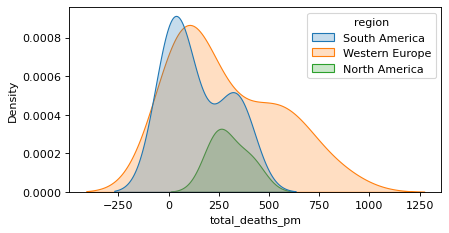

In [13]:
# 1. kdeplot recall
sns.kdeplot(data=high_regions,
            x='total_deaths_pm',
           hue='region', fill=True)

<Axes: xlabel='region', ylabel='total_deaths_pm'>

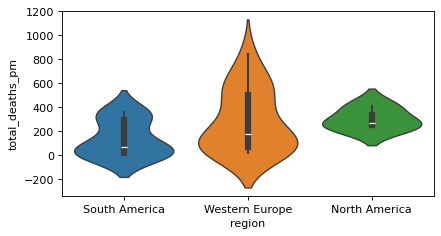

In [16]:
# 2. violinplot recall
sns.violinplot(data=high_regions,
              x='region',
              y='total_deaths_pm', hue='region')


<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
# 1. kdeplot
sns.kdeplot(high_regions, x='total_deaths_pm', hue='region', fill=True)
plt.show()

# 2. violinplot
sns.violinplot(data=high_regions, y='region', x='total_deaths_pm')
plt.show()
```

</details>

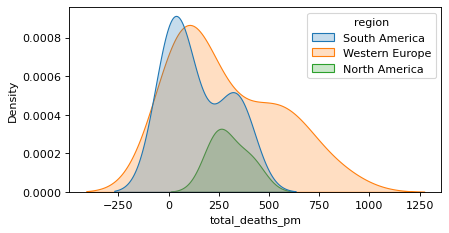

In [24]:
# kdeplot: all three curves sum to 1

sns.kdeplot(high_regions, x='total_deaths_pm', hue='region', fill=True);

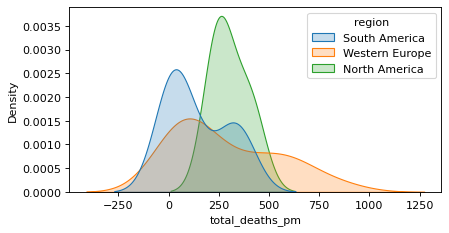

In [23]:
# kdeplot: common_norm=False
#   each individual subset sums to 1...apparently

sns.kdeplot(high_regions, x='total_deaths_pm', hue='region', fill=True, common_norm=False);

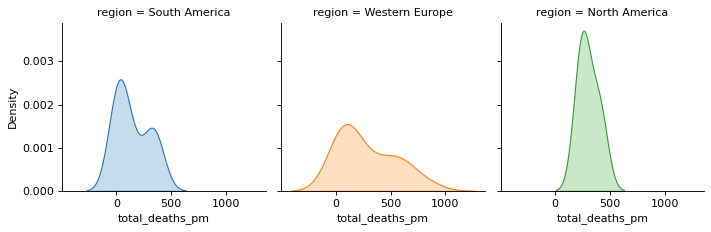

In [29]:
# kde + FacetGrid: individual subsets sum to 1

g = sns.FacetGrid(high_regions, col='region', hue='region')
g.map(sns.kdeplot, 'total_deaths_pm', fill=True)
plt.tight_layout();

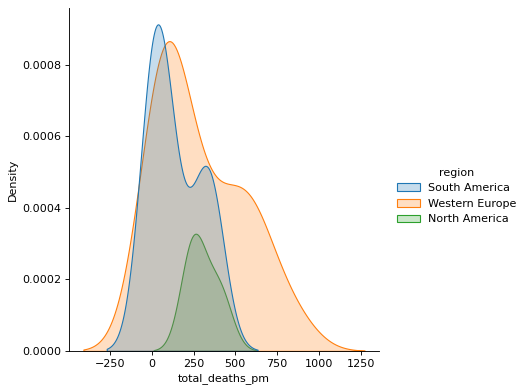

In [28]:
# displot: all subsets sum to 1

sns.displot(high_regions, x='total_deaths_pm', hue='region', kind='kde', fill=True);

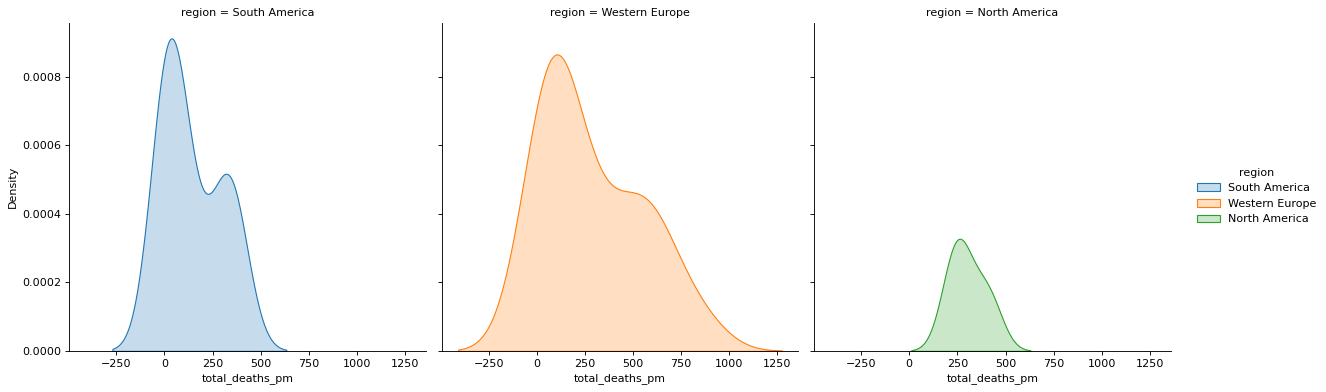

In [30]:
# displot is consistent
#    when we group by region, the scaling is the SAME
sns.displot(data=high_regions, x='total_deaths_pm',
            hue='region', kind='kde', fill=True, col='region');

---
## 2. `displot` — Faceted Distribution Plots

### 📋 Board Reference

`sns.displot` is a **figure-level** function that wraps `histplot`, `kdeplot`, and `ecdfplot` with built-in faceting.

```python
sns.displot(data=df, x='num', col='cat', kind='hist')   # faceted histogram
sns.displot(data=df, x='num', col='cat', kind='kde')    # faceted KDE
sns.displot(data=df, x='num', hue='cat', fill=True)     # overlapping KDE
```

| `kind=` | Plot type |
|---------|-----------|
| `'hist'` (default) | Histogram |
| `'kde'` | KDE (smooth density) |
| `'ecdf'` | Empirical CDF |

**Advantage over FacetGrid:** Less boilerplate — faceting is built in.


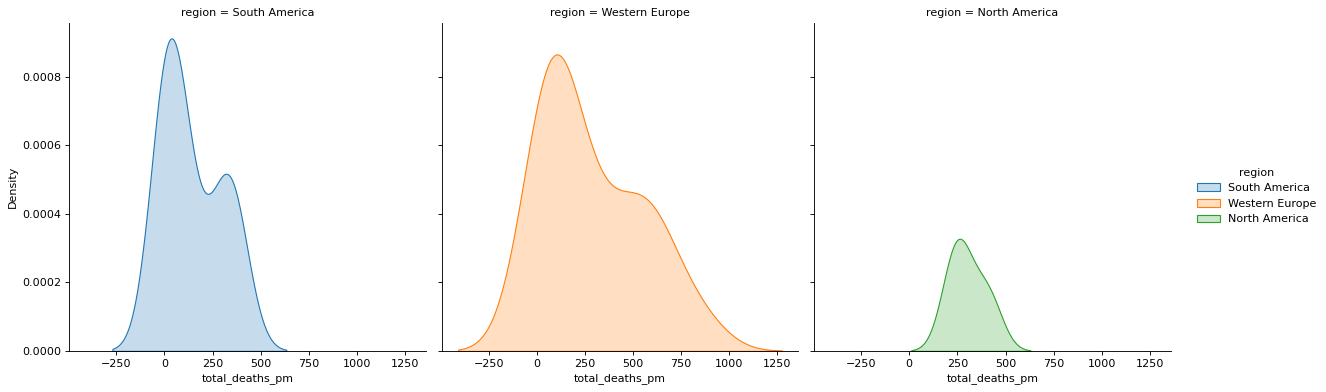

In [17]:
# displot — faceted KDE, one panel per region
sns.displot(data=high_regions, x='total_deaths_pm',
            hue='region', kind='kde', fill=True, col='region');


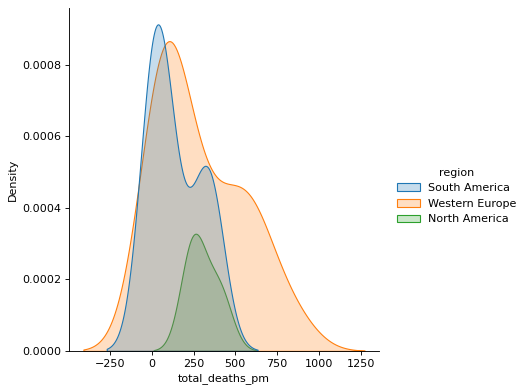

In [18]:
# displot — overlapping KDE with hue only (no faceting)
sns.displot(data=high_regions, x='total_deaths_pm',
            hue='region', kind='kde', fill=True);


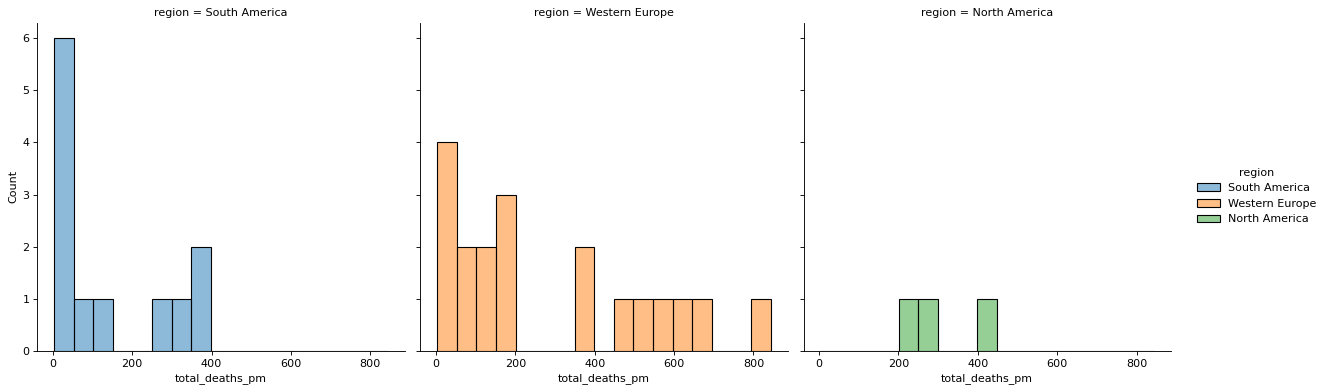

In [32]:
# displot — histogram with binwidth
sns.displot(data=high_regions, x='total_deaths_pm',
            col='region', hue='region', binwidth=50);


---
### 🔬 Explore 1 — `displot`

1. Use `sns.displot` to make a **faceted histogram** of `gdp_per_capita` by `region`  
   (use all regions, `col='region'`, `col_wrap=4`).  
   Add `binwidth=5000`. Which regions have the most spread?

2. Use `kind='kde'` and `fill=True` to make an **overlapping density plot** of `median_age`  
   for `high_regions`. Add `hue='region'`.

3. Use `kind='ecdf'` on `total_cases_pm` for the 3 high-covid regions.  
   What does an ECDF tell you that a histogram doesn't?

4. **Bonus**: On any displot, call `.set(xlim=(0, 100000))` on the result —  
   how do you control axis limits on figure-level plots?


In [34]:
# 1. displot histogram gdp_per_capita all regions
#    use col='region', col_wrap=4
#  try binwidth
#  try a kde, try filling the kde with a color 




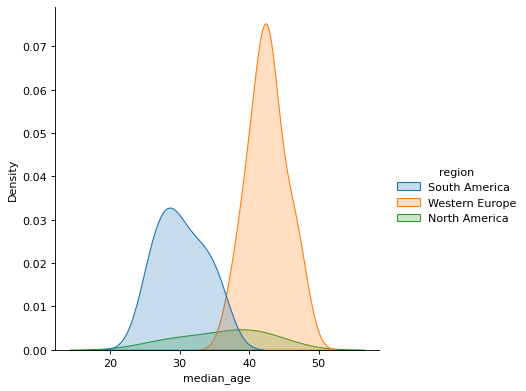

In [38]:
# 2. displot KDE median_age for high_regions




In [41]:
# 3. displot ECDF total_cases_pm
#    kind=ecdf



**What does the ECDF tell you?** *(double-click to edit)*

ECDF = empirical cumulative distribution function


*Your answer here*

In [ ]:
# 4. Bonus: set axis limits on displot


<details>
<summary>💡 One approach — click to peek</summary>
<br>

*ECDF (empirical CDF): the y-value at any x tells you 'what fraction of countries had fewer than x cases per million'. Great for comparing distributions without assuming a shape.*

```python
# 1. Faceted histogram of GDP
g = sns.displot(data=covid, x='gdp_per_capita', col='region',
                hue='region', col_wrap=4, binwidth=5000)
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

# 2. Overlapping KDE of median age
sns.displot(data=high_regions, x='median_age', hue='region',
            kind='kde', fill=True)
plt.show()

# 3. ECDF
sns.displot(data=high_regions, x='total_cases_pm', hue='region', kind='ecdf')
plt.show()
# ECDF shows: what fraction of countries are BELOW a given value?
# The y-axis is cumulative probability (0→1)

# 4. Axis limits on figure-level plot
g = sns.displot(data=covid, x='gdp_per_capita', hue='region',
                kind='kde', fill=True)
g.set(xlim=(0, 100000))
plt.show()
```

</details>

---
## 3. `relplot` — Faceted Relationship Plots


`sns.relplot` is the figure-level version of `scatterplot` and `lineplot` with built-in faceting.

```python
sns.relplot(data=df, x='num', y='num2', col='cat', kind='scatter')
sns.relplot(data=df, x='num', y='num2', row='cat2', col='cat', hue='cat3')
```

| `kind=` | Plot type |
|---------|-----------|
| `'scatter'` (default) | Scatter plot |
| `'line'` | Line plot (useful for time series) |

**Advantage:** Handles `col=`, `row=`, and `hue=` all at once — great for multi-faceted investigation.


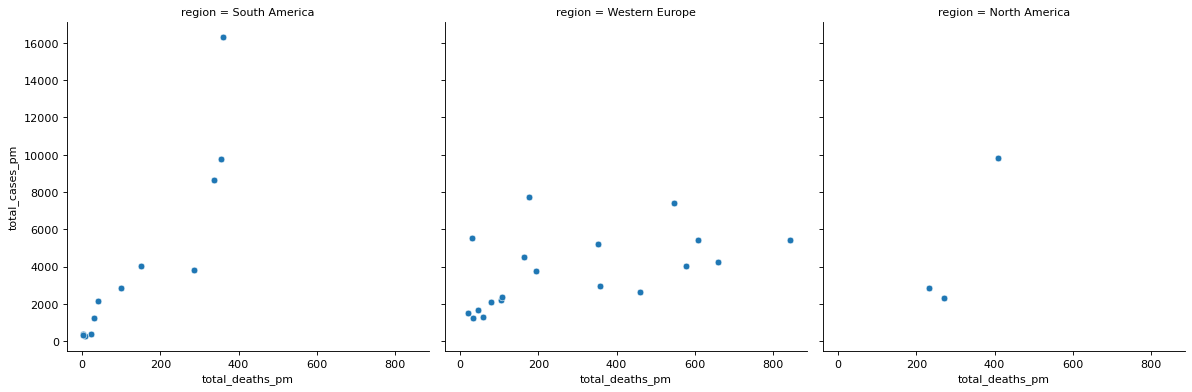

In [42]:
# relplot — faceted scatter
sns.relplot(data=high_regions,
            x='total_deaths_pm',
            y='total_cases_pm',
            col='region', kind='scatter');


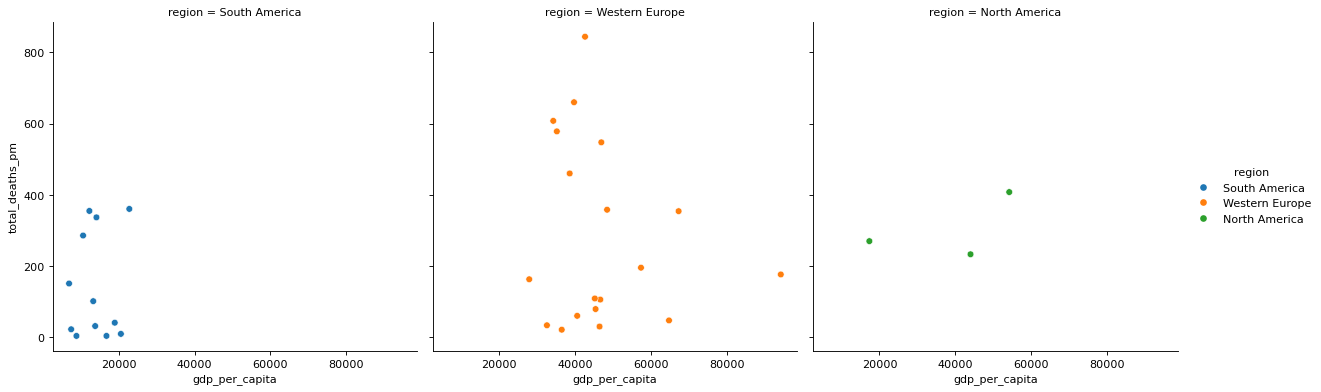

In [48]:
# relplot with hue + col
sns.relplot(data=high_regions,
            x='gdp_per_capita',
            y='total_deaths_pm',
            col='region',
            hue='region',
            kind='scatter');


---
### 🔬 Explore 2 — `relplot`

1. Use `sns.relplot` to make a **faceted scatter** of `gdp_per_capita` vs `total_cases_pm`  
   with `col='region'` and `col_wrap=3` (all regions). Which region has the strangest pattern?

2. Make a `relplot` of `median_age` (x) vs `total_deaths_pm` (y) for the 3 high-covid regions,  
   with `col='region'`. Size the points by `pop_density`.

3. **Discussion**: For this Covid data, which visualization from the last two classes  
   was most informative to you and why?

4. **Bonus**: Try `kind='line'` on the flight delays dataset below:


In [49]:
# For bonus: flight delays
flights = pd.read_csv('flight_delays.csv')
flights['Flight_Date'] = pd.to_datetime(flights['Flight_Date'])
flights['Year'] = flights['Flight_Date'].dt.year
flights.head(3)


,Flight_Date,Airline_Name,Origin_City,Destination_City,Scheduled_Departure_Time,Actual_Departure_Time,Departure_Delay_Minutes,Scheduled_Arrival_Time,Actual_Arrival_Time,Arrival_Delay_Minutes,...,Cancellation_Code,Diverted_Flag,Scheduled_Elapsed_Time_Minutes,Actual_Elapsed_Time_Minutes,Carrier_Delay_HH_MM,Weather_Delay_HH_MM,NAS_Delay_HH_MM,Security_Delay_HH_MM,Late_Aircraft_Delay_HH_MM,Year
0,2019-12-03,JetBlue Airways,"Fort Lauderdale, FL","Boston, MA",06:10,06:03,-7.0,09:14,10:18,64.0,...,Not Cancelled,Not Diverted,184.0,255.0,26:04,04:44,01:04,01:38,03:37,2019
1,2019-01-26,American Airlines Inc.,"Las Vegas, NV","Miami, FL",12:38,12:32,-6.0,20:20,20:15,-5.0,...,Not Cancelled,Not Diverted,282.0,283.0,30:38,14:28,02:50,04:39,08:23,2019
2,2023-08-25,Alaska Airlines Inc.,"Seattle, WA","Pittsburgh, PA",09:35,09:27,-8.0,17:14,16:51,-23.0,...,Not Cancelled,Not Diverted,279.0,264.0,08:27,16:37,03:22,04:52,01:49,2023


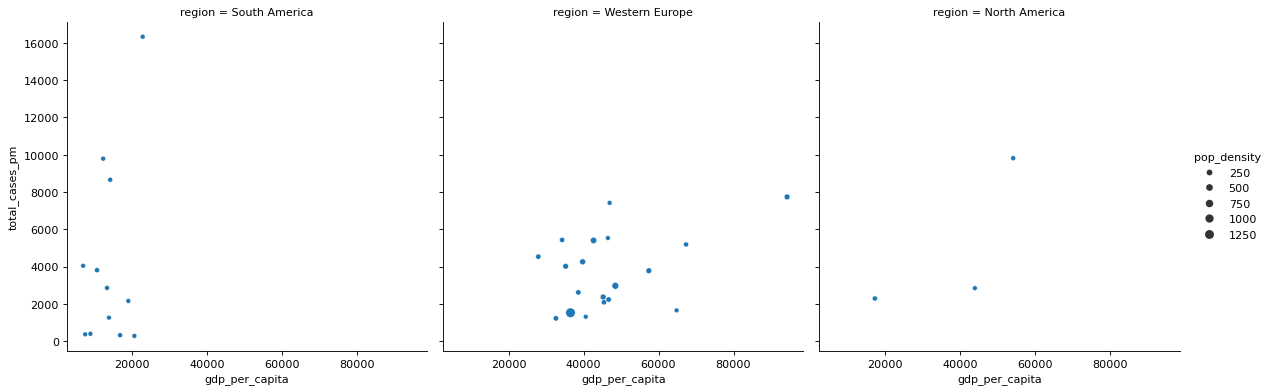

In [53]:
# 1. relplot GDP vs cases, all regions




In [ ]:
# 2. relplot median_age vs deaths, sized by pop_density


In [ ]:
# BoOoOoNuSsS



**Answer to Q3 — Most informative viz:** *(double-click to edit)*

*Your answer here*

In [ ]:
# 4. Bonus: relplot on flight delays


<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
# 1. GDP vs cases, all regions
g = sns.relplot(data=covid, x='gdp_per_capita', y='total_cases_pm',
                col='region', col_wrap=3)
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

# 2. Median age vs deaths, sized by density
sns.relplot(data=high_regions,
            x='median_age', y='total_deaths_pm',
            col='region', size='pop_density', hue='region')
plt.show()

# 4. Bonus: flight delays by year
sns.displot(data=flights, x='Departure_Delay_Minutes',
            col='Year', binwidth=5)
for ax in plt.gcf().axes:
    ax.set_xlim(-20, 100)
plt.tight_layout()
plt.show()
```

</details>

---
## 4. 🔬 Titanic EDA Activity
![Titanic](https://www.arabnews.com/sites/default/files/styles/n_670_395/public/2017/12/17/1055441-861357887.jpg?itok=AwmCDd2t)

Now you put it all together: a full EDA on the **Titanic dataset**.  
Work through the tasks below — there are no single right answers, just good and weak analyses.

This dataset is a fun dataset and [Kaggle runs ML competitions](https://www.kaggle.com/competitions/titanic)

In [54]:
plt.style.use('ggplot')
titanic = sns.load_dataset('titanic')
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [55]:
titanic.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [56]:
titanic.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## Titanic Dataset Metadata

The Titanic dataset contains information about passengers aboard the RMS Titanic, which sank on April 15, 1912. The dataset is commonly used for exploring relationships between passenger characteristics and survival outcomes.

| Variable | Type | Description |
|---------|------|-------------|
| `survived` | Binary (0/1) | Survival indicator (0 = did not survive, 1 = survived) |
| `pclass` | Categorical / Ordinal | Passenger class (1 = First class, 2 = Second class, 3 = Third class) |
| `sex` | Categorical | Passenger gender (male, female) |
| `age` | Numeric | Age of the passenger in years |
| `sibsp` | Integer | Number of siblings or spouses aboard the Titanic |
| `parch` | Integer | Number of parents or children aboard the Titanic |
| `fare` | Numeric | Ticket fare paid by the passenger |
| `embarked` | Categorical | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |
| `class` | Categorical | Passenger class as a label (First, Second, Third) |
| `who` | Categorical | Passenger category (man, woman, child) |
| `adult_male` | Boolean | Indicates if passenger is an adult male |
| `deck` | Categorical | Deck level of the passenger cabin |
| `embark_town` | Categorical | Full name of embarkation town |
| `alive` | Categorical | Survival status as text (yes/no) |
| `alone` | Boolean | Indicates if the passenger traveled alone |

### Task 1 — Visualize Missing Data

Use a heatmap to visualize where the null values are.  
*(Hint: pass `titanic.isnull()` as the data to `sns.heatmap`)*


In [ ]:
# Heatmap of null values


<details>
<summary>💡 One approach — click to peek</summary>
<br>

*The 'age' column has many missing values. The 'deck' column is almost entirely missing — may need to be dropped.*

```python
plt.figure(figsize=(10, 4))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values in Titanic Dataset (yellow = missing)')
plt.tight_layout()
plt.show()
```

</details>

**What do you notice about the missing data?** *(double-click to edit)*

*Your answer here*

### Task 2 — Correlation Heatmap

Use a heatmap to visualize correlations among the **numeric** columns.  
What do you notice about `survived`?


In [ ]:
# Correlation heatmap of numeric columns


<details>
<summary>💡 One approach — click to peek</summary>
<br>

*Note: pclass has a negative correlation with survived — lower class numbers (1=first class) survived more.*

```python
corrmat = titanic.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corrmat, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Titanic Correlation Matrix')
plt.tight_layout()
plt.show()
```

</details>

**What do you notice about the `survived` column?** *(double-click to edit)*

*Your answer here*

### Task 3 — Count Plots

Create subplots showing the count of each category for:  
`survived`, `pclass`, `sex`, `sibsp`, `parch`, `embark_town`, `alone`

*(Hint: use `plt.subplots` + a loop over columns)*


In [ ]:
# Subplot grid of countplots


<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
cat_cols = ['survived', 'pclass', 'sex', 'sibsp', 'parch', 'embark_town', 'alone']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 3))

for i, col in enumerate(cat_cols):
    sns.countplot(data=titanic, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Category Counts — Titanic', y=1.05)
plt.tight_layout()
plt.show()
```

</details>

**Observations from count plots:** *(double-click to edit)*

*Your answer here*

### Task 4 — Survival by Class and Sex

Create a plot that shows survived vs. not-survived counts for each `pclass`, faceted by `sex`.  
*(Hint: `sns.countplot(x='pclass', hue='survived')` + `sns.FacetGrid` or `displot`)*


In [ ]:
# Survival by pclass, faceted by sex


<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
g = sns.FacetGrid(titanic, col='sex', hue='survived', palette={0:'salmon', 1:'steelblue'})
g.map(sns.countplot, 'pclass')
g.add_legend(title='Survived')
g.set_axis_labels('Passenger Class', 'Count')
g.set_titles(col_template='{col_name}')
plt.tight_layout()
plt.show()
```

</details>

### Task 5 — Age Distributions by Survival

Create a visualization that compares the age distribution of survivors vs. non-survivors.  
Use `sns.kdeplot` or `sns.boxplot`.


In [ ]:
# Age distribution — survived vs not survived


<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
# Option 1: kdeplot
sns.kdeplot(data=titanic.dropna(subset=['age']),
            x='age', hue='survived', fill=True)
plt.title('Age Distribution by Survival')
plt.show()

# Option 2: boxplot
sns.boxplot(data=titanic, x='survived', y='age')
plt.title('Age vs Survival')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()
```

</details>

**What does this tell you about age and survival?** *(double-click to edit)*

*Your answer here*

---
## Appendix — `displot` and `relplot` Reference

```python
# displot — figure-level distribution plots
sns.displot(data=df, x='num', col='cat', kind='hist', binwidth=10)
sns.displot(data=df, x='num', hue='cat', kind='kde', fill=True)
sns.displot(data=df, x='num', hue='cat', kind='ecdf')
g = sns.displot(...)
g.set(xlim=(0, 100))         # control axis limits
g.set_titles('{col_name}')   # panel titles

# relplot — figure-level scatter / line plots
sns.relplot(data=df, x='num', y='num2', col='cat', kind='scatter')
sns.relplot(data=df, x='num', y='num2', row='cat', col='cat2', hue='cat3', size='num3')

# Common EDA combination for categorical target
sns.countplot(data=df, x='cat', hue='target')
g = sns.FacetGrid(df, col='cat', hue='target')
g.map(sns.countplot, 'other_cat')
g.add_legend()
```
